## Logistic Regression 모델

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import joblib

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
)

In [3]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [4]:
PROCESSED_DIR = r"C:\Users\SAMSUNG\OneDrive\바탕 화면\전건우\GitHub\Animal-Shelter-Analytics\code"

In [5]:
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns")

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (98253, 65)  X_test: (24601, 65)


In [6]:
# 스케일링
# One-hot encoding된 더미 변수는 그대로 두고, 연속형 변수만 표준화
numeric_cols = [c for c in ["age_days", "intake_month"] if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [8]:
# 모델 학습
# 클래스에 약간의 불균형 존재 -> class_weight='balanced'로 보정
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [9]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
 
print("\n[성능 지표]")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
 
print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=["Not Adoption", "Adoption"]))


[성능 지표]
Accuracy : 0.700
Precision: 0.635
Recall   : 0.771
F1-score : 0.696
ROC-AUC  : 0.771

[Classification Report]
              precision    recall  f1-score   support

Not Adoption       0.78      0.64      0.70     13627
    Adoption       0.63      0.77      0.70     10974

    accuracy                           0.70     24601
   macro avg       0.71      0.71      0.70     24601
weighted avg       0.71      0.70      0.70     24601



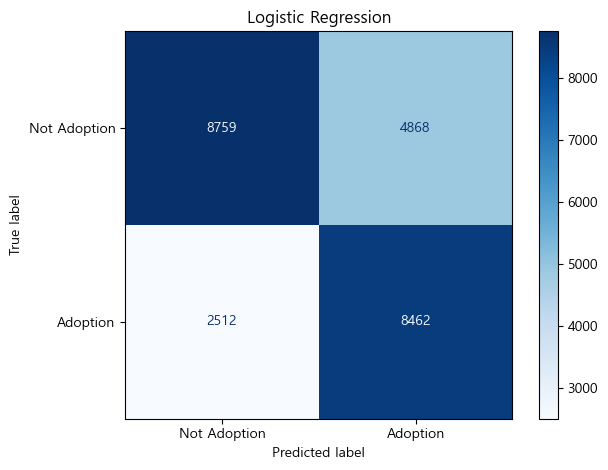

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Adoption", "Adoption"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression")
plt.tight_layout()
plt.savefig("logreg_confusion_matrix.png", dpi=120)
plt.show()

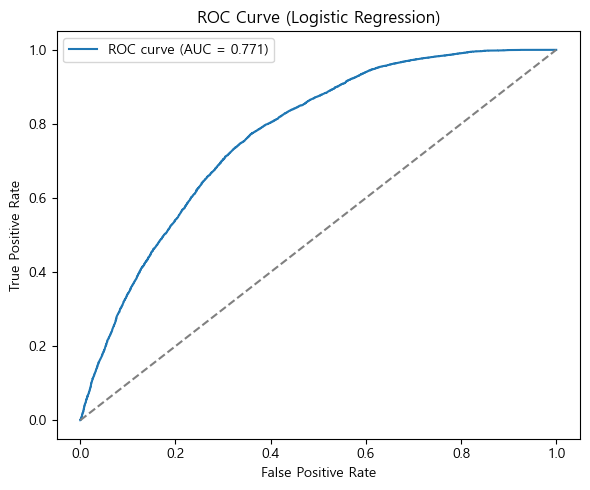

In [11]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.savefig("logreg_roc_curve.png", dpi=120)
plt.show()


[영향력 상위 15개 변수 - 계수/오즈비]
                             feature  coefficient  odds_ratio
                Intake Type_Wildlife    -2.663592    0.069697
           Intake Type_Public Assist    -1.702246    0.182274
      Intake Type_Euthanasia Request    -1.659010    0.190327
                         sex_Unknown    -1.590735    0.203776
           sterilized_status_Unknown    -1.590735    0.203776
                   breed_grouped_Bat    -1.141853    0.319227
                            has_name     1.141084    3.130160
               breed_grouped_Bat Mix    -1.034970    0.355237
                        age_group_성체    -0.796773    0.450781
breed_grouped_Domestic Shorthair Mix    -0.753299    0.470811
                       age_group_청년기    -0.730554    0.481642
          breed_grouped_Pit Bull Mix    -0.659266    0.517231
               Intake Condition_Sick    -0.631009    0.532055
    breed_grouped_Domestic Shorthair    -0.623392    0.536123
           breed_grouped_Siamese Mix    -0.6

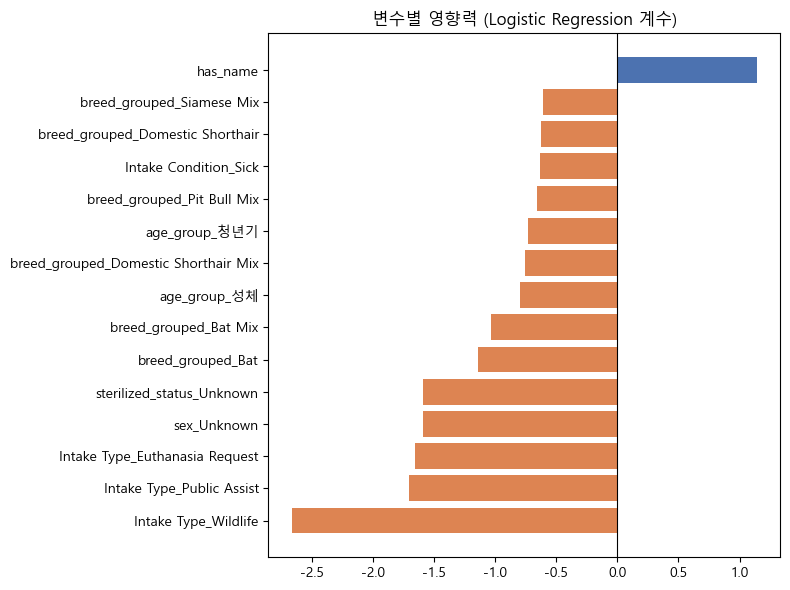

In [12]:
# 계수 해석
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": model.coef_[0],
})
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)
 
print("\n[영향력 상위 15개 변수 - 계수/오즈비]")
print(coef_df.head(15).to_string(index=False))
 
plt.figure(figsize=(8, 6))
top15 = coef_df.head(15).sort_values("coefficient")
colors = ["#DD8452" if c < 0 else "#4C72B0" for c in top15["coefficient"]]
plt.barh(top15["feature"], top15["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("변수별 영향력 (Logistic Regression 계수)")
plt.tight_layout()
plt.savefig("logreg_coefficients.png", dpi=120)
plt.show()

In [13]:
joblib.dump({"model": model, "scaler": scaler, "numeric_cols": numeric_cols}, "logreg_model.pkl")
print("\n모델 저장 완료: logreg_model.pkl")


모델 저장 완료: logreg_model.pkl
